In [48]:
# ## Imports

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    classification_report, roc_auc_score,
    recall_score, precision_score, accuracy_score,
)

MODEL_BASE_PATH  = Path("../baseline_models/cardio_xgb_baseline_model.pkl")
MODEL_REFINED_PATH  = Path("../refined_models")

OUTPUT_DIR = Path("../../outputs/models")


In [51]:
# ## 1 · Load Test Sets & Models

test_df    = pd.read_csv("../../data/test_train_val_sets/cardio_baseline_test.csv")
test_fe_df = pd.read_csv("../../data/test_train_val_sets/cardio_fe_test.csv")


X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]
X_test_fe = test_fe_df.drop(columns=["cardio"])
y_test_fe = test_fe_df["cardio"]

female_mask = test_df["gender"].values == 0
male_mask   = test_df["gender"].values == 1

def load(path):
    with open(path, "rb") as f:
        return pickle.load(f)

models = {
    "Baseline":    (load(MODEL_BASE_PATH), X_test),
    "Tuned":       (load(MODEL_REFINED_PATH/ "cardio_xgb_tuned.pkl"),           X_test),
    "Monotone":    (load(MODEL_REFINED_PATH/ "cardio_xgb_monotone.pkl"),        X_test),   # uses clipped X_test
    "Weighted":    (load(MODEL_REFINED_PATH/ "cardio_xgb_weighted.pkl"),        X_test),
    "Constrained": (load(MODEL_REFINED_PATH/ "cardio_xgb_constrained.pkl"),     X_test),
    "FE":          (load(MODEL_REFINED_PATH/ "cardio_xgb_fe.pkl"),              X_test_fe),
}

In [52]:
# X_test and y_test are the held‑out test set
assert len(X_test) == len(y_test)

import json

with open("../../config/dataset_split_sizes.json", "r") as f:
    expected = json.load(f)

assert len(test_df)  == expected["test"],  "Test size mismatch"
assert len(test_fe_df)  == expected["test"],  "Test size mismatch"

print("Dataset sizes validated.")


Dataset sizes validated.


In [53]:
# ## 2 · Bootstrap CI Helper

def bootstrap_ci(y_true, y_pred, y_prob, metric_fn, n_bootstraps=1000, ci=0.95):
    scores, rng = [], np.random.RandomState(42)
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_pred[idx], y_prob[idx]))
    scores = np.sort(scores)
    lo = scores[int((1 - ci) / 2 * len(scores))]
    hi = scores[int((1 + ci) / 2 * len(scores))]
    return np.mean(scores), lo, hi

def auroc(yt, yp, ypr):     return roc_auc_score(yt, ypr)
def accuracy(yt, yp, ypr):  return accuracy_score(yt, yp)
def recall(yt, yp, ypr):    return recall_score(yt, yp)
def precision(yt, yp, ypr): return precision_score(yt, yp)

In [46]:
# ## 3 · Evaluate All Models

for model_name, (model, X) in models.items():
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # choose correct y_test depending on model
    if model_name == "FE":
        y_true = y_test_fe
    else:
        y_true = y_test

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    # validation checks
    assert len(y_pred) == len(y_true)
    assert len(y_prob) == len(y_true)
    
    # Gender masks applied to the correct X
    is_fe       = model_name == "FE"
    feat_mask   = female_mask  # same index, gender col not in FE features
    
    y_pred_f = model.predict(X[female_mask])
    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    y_pred_m = model.predict(X[male_mask])
    y_prob_m = model.predict_proba(X[male_mask])[:, 1]

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    for label, yt, yp, ypr in [
        ("Overall", y_test.values,        y_pred,   y_prob),
        ("Female",  y_test[female_mask].values, y_pred_f, y_prob_f),
        ("Male",    y_test[male_mask].values,   y_pred_m, y_prob_m),
    ]:
        print(f"\n── {label} ──────────────────────────────")
        print(classification_report(yt, yp))
        for name, fn in [("AUROC", auroc), ("Accuracy", accuracy),
                         ("Recall", recall), ("Precision", precision)]:
            m, lo, hi = bootstrap_ci(yt, yp, ypr, fn)
            print(f"  {name:<12}: {m:.3f}  ({lo:.3f} – {hi:.3f})")


  Baseline

── Overall ──────────────────────────────
              precision    recall  f1-score   support

           0       0.72      0.78      0.74      5160
           1       0.75      0.69      0.72      5067

    accuracy                           0.73     10227
   macro avg       0.73      0.73      0.73     10227
weighted avg       0.73      0.73      0.73     10227

  AUROC       : 0.796  (0.787 – 0.805)
  Accuracy    : 0.731  (0.723 – 0.740)
  Recall      : 0.685  (0.674 – 0.697)
  Precision   : 0.750  (0.738 – 0.763)

── Female ──────────────────────────────
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      3369
           1       0.75      0.69      0.72      3280

    accuracy                           0.74      6649
   macro avg       0.74      0.73      0.73      6649
weighted avg       0.74      0.74      0.73      6649

  AUROC       : 0.803  (0.792 – 0.813)
  Accuracy    : 0.735  (0.724 – 0.746)
  Recall      :

KeyboardInterrupt: 

In [ ]:
# ## 4 · Side-by-Side Summary Table

rows = []
for model_name, (model, X) in models.items():
    for label, mask in [("Overall", slice(None)), ("Female", female_mask), ("Male", male_mask)]:
        yt  = y_test.values[mask]
        yp  = model.predict(X[mask])
        ypr = model.predict_proba(X[mask])[:, 1]
        rows.append({
            "Model":     model_name,
            "Subset":    label,
            "AUROC":     round(roc_auc_score(yt, ypr), 3),
            "Recall":    round(recall_score(yt, yp), 3),
            "Precision": round(precision_score(yt, yp), 3),
            "Accuracy":  round(accuracy_score(yt, yp), 3),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

      Model  Subset  AUROC  Recall  Precision  Accuracy
   Baseline Overall  0.797   0.692      0.747     0.731
   Baseline  Female  0.803   0.699      0.750     0.737
   Baseline    Male  0.786   0.681      0.740     0.721
      Tuned Overall  0.797   0.692      0.749     0.732
      Tuned  Female  0.803   0.699      0.749     0.736
      Tuned    Male  0.785   0.679      0.748     0.725
   Monotone Overall  0.797   0.692      0.747     0.731
   Monotone  Female  0.803   0.699      0.750     0.736
   Monotone    Male  0.785   0.678      0.742     0.722
   Weighted Overall  0.784   0.709      0.734     0.728
   Weighted  Female  0.792   0.710      0.740     0.734
   Weighted    Male  0.770   0.707      0.723     0.718
Constrained Overall  0.793   0.660      0.761     0.729
Constrained  Female  0.800   0.665      0.764     0.734
Constrained    Male  0.779   0.650      0.755     0.720
         FE Overall  0.797   0.781      0.694     0.721
         FE  Female  0.803   0.784      0.699   

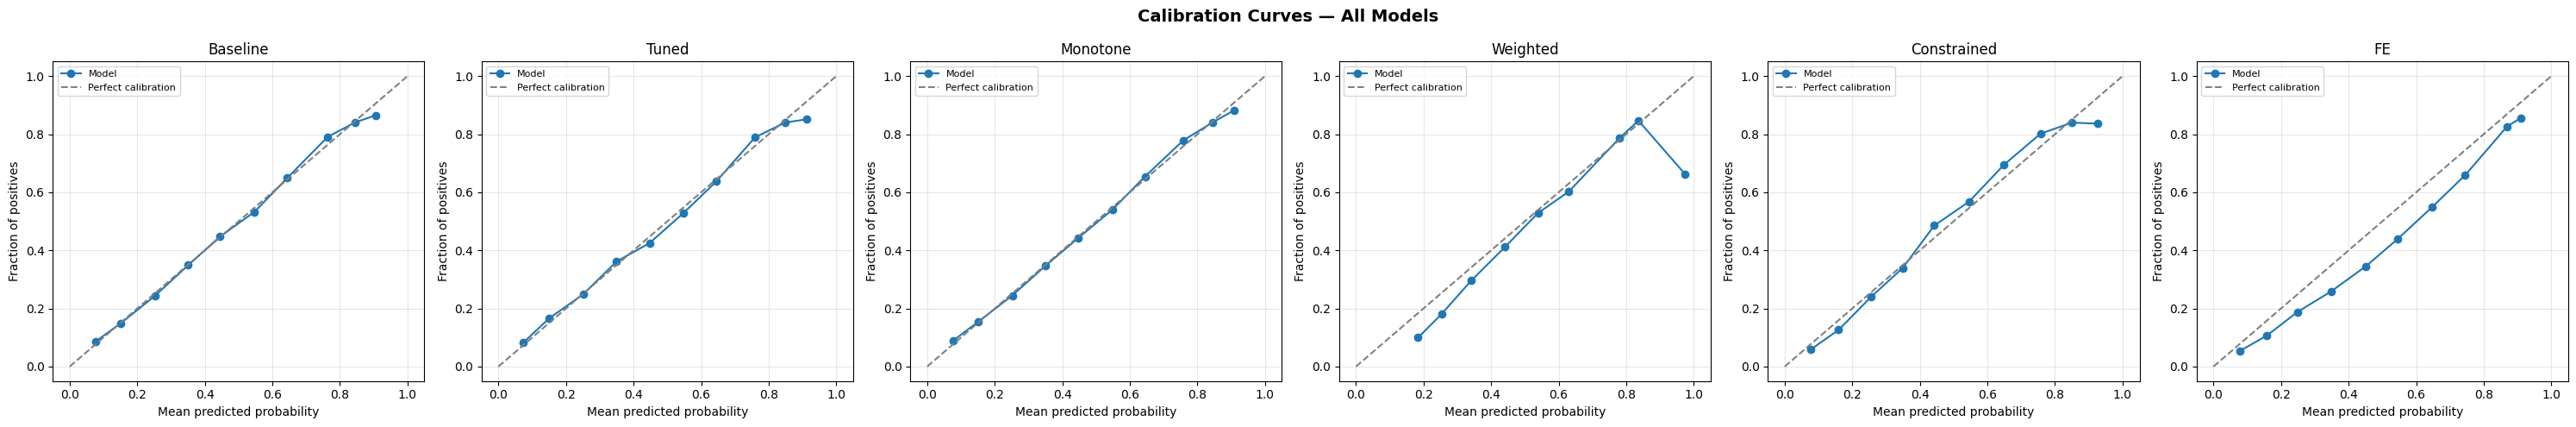

In [ ]:
# ## 4 · Calibration

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))
fig.suptitle("Calibration Curves — All Models", fontsize=14, fontweight="bold")

for ax, (model_name, (model, X)) in zip(axes, models.items()):
    y_prob = model.predict_proba(X)[:, 1]
    
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    
    ax.plot(prob_pred, prob_true, marker="o", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
    ax.set_title(model_name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

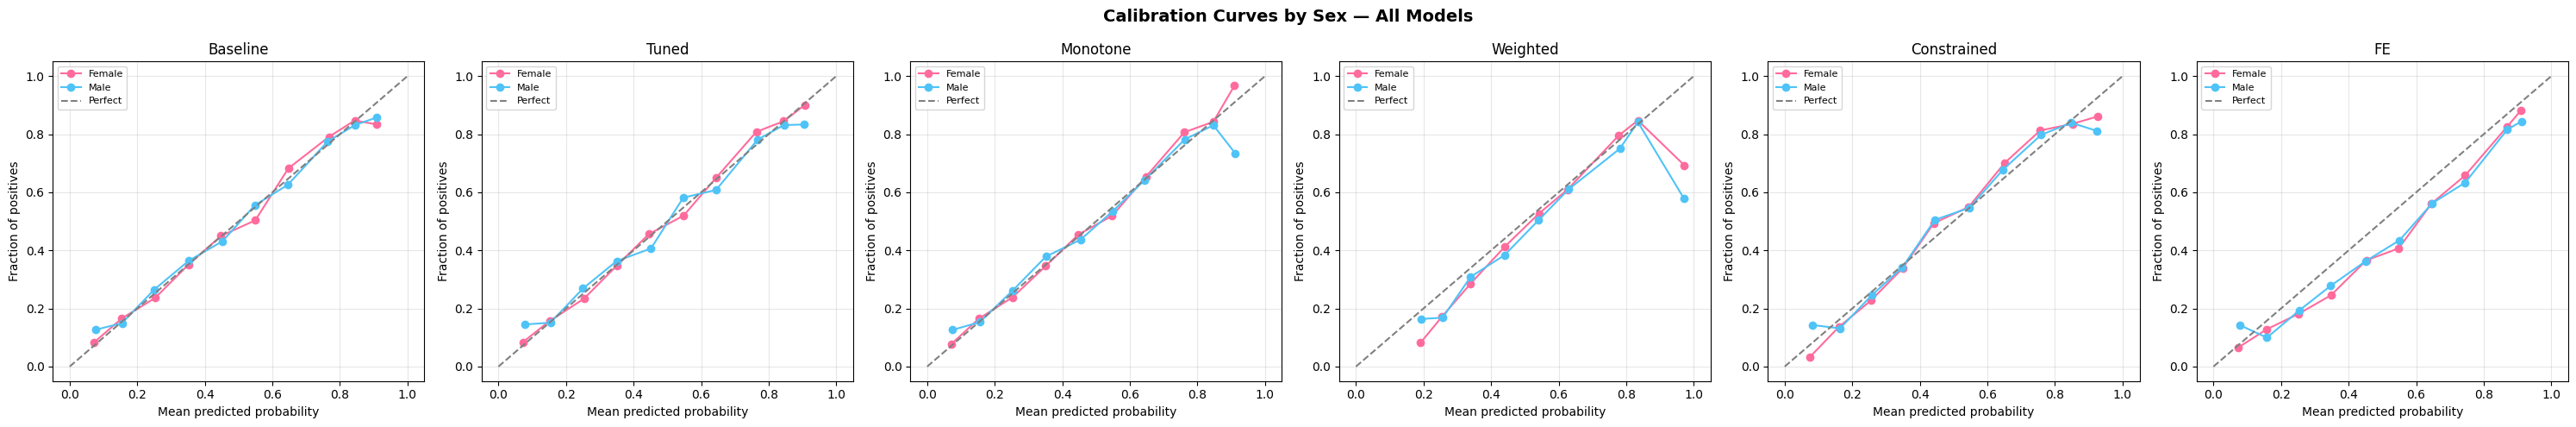


Model            F mean pred   F actual   F diff  M mean pred   M actual   M diff
--------------------------------------------------------------------------------
Baseline              0.4946     0.4933  +0.0013       0.4995     0.4994  +0.0001
Tuned                 0.4952     0.4933  +0.0019       0.4991     0.4994  -0.0004
Monotone              0.4949     0.4933  +0.0016       0.4998     0.4994  +0.0003
Weighted              0.5374     0.4933  +0.0441       0.5455     0.4994  +0.0460
Constrained           0.4954     0.4933  +0.0021       0.4983     0.4994  -0.0012
FE                    0.5669     0.4933  +0.0736       0.5737     0.4994  +0.0743


<Figure size 640x480 with 0 Axes>

In [54]:
# ## 4b · Sex-Stratified Calibration Curves

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))
fig.suptitle("Calibration Curves by Sex — All Models", fontsize=14, fontweight="bold")

for ax, (model_name, (model, X)) in zip(axes, models.items()):
    
    # Female
    y_prob_f = model.predict_proba(X[female_mask])[:, 1]
    prob_true_f, prob_pred_f = calibration_curve(y_test[female_mask], y_prob_f, n_bins=10)
    
    # Male
    y_prob_m = model.predict_proba(X[male_mask])[:, 1]
    prob_true_m, prob_pred_m = calibration_curve(y_test[male_mask], y_prob_m, n_bins=10)
    
    ax.plot(prob_pred_f, prob_true_f, marker="o", color="#ff6b9d", label="Female")
    ax.plot(prob_pred_m, prob_true_m, marker="o", color="#4fc3f7", label="Male")
    ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect")
    
    ax.set_title(model_name)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / "calibration_by_sex.png", dpi=150, bbox_inches="tight")


# ── Calibration in the large by sex ──────────────────────
print(f"\n{'Model':<15} {'F mean pred':>12} {'F actual':>10} {'F diff':>8} {'M mean pred':>12} {'M actual':>10} {'M diff':>8}")
print("-" * 80)

for model_name, (model, X) in models.items():
    prob_f    = model.predict_proba(X[female_mask])[:, 1]
    prob_m    = model.predict_proba(X[male_mask])[:, 1]
    actual_f  = y_test[female_mask].mean()
    actual_m  = y_test[male_mask].mean()
    diff_f    = prob_f.mean() - actual_f
    diff_m    = prob_m.mean() - actual_m
    print(f"{model_name:<15} {prob_f.mean():>12.4f} {actual_f:>10.4f} {diff_f:>+8.4f} {prob_m.mean():>12.4f} {actual_m:>10.4f} {diff_m:>+8.4f}")

In [ ]:
# ── Brier Score (summary calibration metric) ──────────────
from sklearn.metrics import brier_score_loss

print(f"{'Model':<15} {'Brier Score':>12}  (lower = better, 0.25 = no skill)")
print("-" * 35)
for model_name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:, 1]
    bs = brier_score_loss(y_test, y_prob)
    print(f"{model_name:<15} {bs:>12.4f}")

Model            Brier Score  (lower = better, 0.25 = no skill)
-----------------------------------
Baseline              0.1821
Tuned                 0.1823
Monotone              0.1823
Weighted              0.1902
Constrained           0.1850
FE                    0.1884
